In [4]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import seaborn as sns
import matplotlib.pyplot as plt

---
## <u>Load Dataset<u>

In [5]:
data = pd.read_csv("thyroid_dataset.csv")
data.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


---
## <u>Split Data<u>

In [6]:
X = data.drop(columns = ["Outlier_label"])
y = data["Outlier_label"]

---
## <u>Scaling<u>

In [7]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_scaled = scaler.fit_transform(X)

---
## <u>PCA<u>

In [9]:
pca = PCA(n_components = 16)
pca.set_output(transform = "pandas")
X_pca = pca.fit_transform(X_scaled)
var_kept = pca.explained_variance_ratio_.sum()
print(var_kept)

0.8215303344077265


---
## <u>Make Model and Predict<u>

In [10]:
isf = IsolationForest(
    n_estimators = 301,
    # contamination = "auto", # this is the number/percentage of outliers in the dataset, we set "auto" when we do not know exactly
    contamination = 0.036,
    random_state = 42
)

labels = isf.fit_predict(X_pca)

---
## <u>Visualize<u>

Text(0.5, 1.0, 'Predicted outliers')

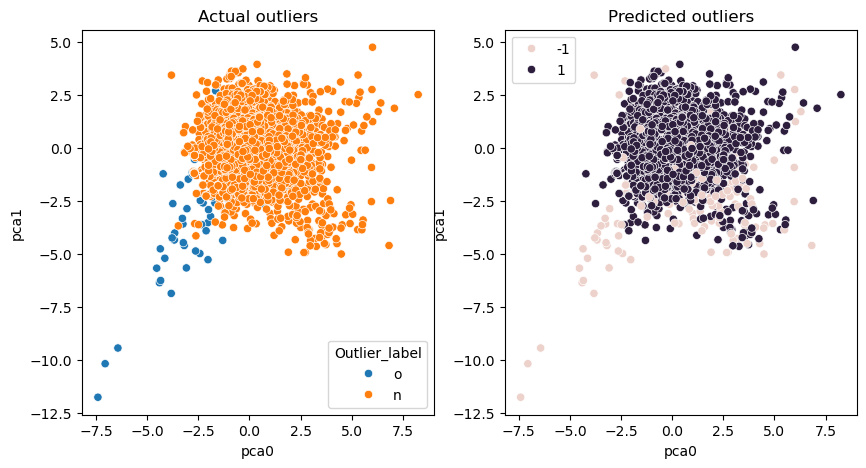

In [11]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

sns.scatterplot(
    ax = ax[0],
    x = X_pca.iloc[:,0],
    y = X_pca.iloc[:,1],
    hue = y
)

sns.scatterplot(
    ax = ax[1],
    x = X_pca.iloc[:,0],
    y = X_pca.iloc[:,1],
    hue = labels
)

ax[0].set_title("Actual outliers")
ax[1].set_title("Predicted outliers")

---
## <u>Checking Categories<u>

In [12]:
print("Outliers/Anomalies : ",np.sum(labels == -1))
print("Normal points : ",np.sum(labels == 1))

Outliers/Anomalies :  249
Normal points :  6667
